# Proyek Analisis Data E-Commerce
- **Nama:** [Hafiz Hafrienda]
- **Email:** [hafizhafrienda2005@gmail.com]
- **ID Dicoding:** [hafiz_hafrienda_GmIC]
- **Dataset:** `E-Commerce Public Dataset`

Notebook ini disusun untuk analisis end-to-end mulai dari pemahaman bisnis, data wrangling, eksplorasi, visualisasi, hingga rekomendasi.

### BUSINESS UNDERSTANDING


Pertanyaan Bisnis SMART
1. **Pertanyaan 1:** Bagaimana tren revenue dan jumlah order per bulan selama periode 2017–2018?

   - **Spesific:** Fokus pada analisis revenue dan jumlah order bulanan.

   - **Measurable:** Dapat dihitung total revenue dan jumlah order setiap bulan.

   - **Action-Oriented:** Hasil membantu tim bisnis mengatur kampanye promosi dan ketersediaan stok.

   - **Relevant:** Relevan untuk memahami performa penjualan dalam periode tertentu.

   - **Time-bound:** Batas waktu pada periode 2017–2018.



2. **Pertanyaan 2:** Kategori produk mana yang menghasilkan revenue tertinggi selama periode ini?

   - **Spesific:** Fokus pada perbandingan revenue antar kategori produk.

   - **Measurable:** Dapat dihitung total revenue untuk setiap kategori.

   - **Action-Oriented:** Hasil dapat digunakan untuk mengoptimalkan fokus pemasaran dan persediaan produk.

   - **Relevant:** Penting untuk memprioritaskan kategori produk yang paling menguntungkan.

   - **Time-bound:** Dibatasi pada data periode 2017–2018.



3. **Pertanyaan 3:** State pelanggan mana yang memberikan kontribusi penjualan terbesar dalam data ini?

   - **Spesific:** Fokus pada identifikasi state dengan kontribusi penjualan tinggi.

   - **Measurable:** Dapat diukur melalui total revenue dan jumlah order per state.

   - **Action-Oriented:** Mempermudah penentuan area geografis untuk strategi pemasaran.

   - **Relevant:** Penting untuk memperkuat penetrasi pasar berdasarkan lokasi pelanggan.

   - **Time-bound:** Dibatasi pada data yang tersedia saat ini.


## 1. Data Loading

Pada bagian ini, semua dataset dari folder `data/` dimuat menggunakan pandas. Setiap dataset diperiksa dengan `head()` dan `info()` untuk memahami struktur dan tipe datanya.

In [2]:
import pandas as pd

customers = pd.read_csv('data/customers_dataset.csv')
geolocation = pd.read_csv('data/geolocation_dataset.csv')
order_items = pd.read_csv('data/order_items_dataset.csv')
order_payments = pd.read_csv('data/order_payments_dataset.csv')
order_reviews = pd.read_csv('data/order_reviews_dataset.csv')
orders = pd.read_csv('data/orders_dataset.csv')
products = pd.read_csv('data/products_dataset.csv')
sellers = pd.read_csv('data/sellers_dataset.csv')
product_category_translation = pd.read_csv('data/product_category_name_translation.csv')

datasets = [
    ('customers', customers),
    ('geolocation', geolocation),
    ('order_items', order_items),
    ('order_payments', order_payments),
    ('order_reviews', order_reviews),
    ('orders', orders),
    ('products', products),
    ('sellers', sellers),
    ('product_category_translation', product_category_translation)
]

for name, df in datasets:
    print(f'=== {name.upper()} ===')
    display(df.head())
    print(df.info())
    print('-' * 80)

=== CUSTOMERS ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None
--------------------------------------------------------------------------------
=== GEOLOCATION ===


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB
None
--------------------------------------------------------------------------------
=== ORDER_ITEMS ===


...

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None
--------------------------------------------------------------------------------
=== SELLERS ===


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
None
--------------------------------------------------------------------------------
=== PRODUCT_CATEGORY_TRANSLATION ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB
None
--------------------------------------------------------------------------------


### Penjelasan singkat setiap dataset

- `customers_dataset.csv`: data pelanggan termasuk `customer_id` dan lokasi dasar.
- `geolocation_dataset.csv`: data lokasi geolokasi yang berisi `customer_id` dan koordinat.
- `order_items_dataset.csv`: detail item per order, harga, subsidi ongkir, dan penjual.
- `order_payments_dataset.csv`: informasi pembayaran per order, termasuk nilai dan jumlah cicilan.
- `order_reviews_dataset.csv`: review pelanggan untuk setiap order.
- `orders_dataset.csv`: header order utama termasuk status dan waktu pembelian.
- `products_dataset.csv`: daftar produk dan kategori asli.
- `sellers_dataset.csv`: informasi penjual, termasuk lokasi penjual.
- `product_category_name_translation.csv`: terjemahan kategori produk ke bahasa Inggris.

## 2. Data Wrangling 

Langkah pertama adalah melakukan agregasi sebelum merge untuk menjaga agar tidak terjadi data explosion.

### 2.1 Agregasi Data

Optimalisasi dilakukan pada setiap dataset yang akan di-join agar setiap order tetap menghasilkan 1 baris informasi.

In [3]:
order_items_agg = order_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_items=('product_id', 'count')
).reset_index()

payments_agg = order_payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    max_installment=('payment_installments', 'max')
).reset_index()

reviews_unique = order_reviews.sort_values('review_id').drop_duplicates('order_id', keep='first')

products_translated = products.merge(
    product_category_translation,
    how='left',
    on='product_category_name'
)

order_category = (
    order_items[['order_id', 'product_id']]
    .merge(
        products_translated[['product_id', 'product_category_name_english']],
        how='left',
        on='product_id'
    )
    .groupby('order_id')['product_category_name_english']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)

order_category.columns = ['order_id', 'primary_category']

print('Order items aggregated:', order_items_agg.shape)
print('Payments aggregated:', payments_agg.shape)
print('Reviews unique:', reviews_unique.shape)
print('Order categories:', order_category.shape)

Order items aggregated: (98666, 4)
Payments aggregated: (99440, 3)
Reviews unique: (98673, 7)
Order categories: (98666, 2)


### Insight Data Agregasi Order
Berdasarkan hasil agregasi data:

Order Items: 98,666 order
Payments: 99,440 order
Reviews: 98,673 order
Order Categories: 98,666 order

Dapat disimpulkan bahwa sebagian besar dataset sudah konsisten, terutama antara order items, reviews, dan categories yang memiliki jumlah order hampir identik. Hal ini menunjukkan bahwa hampir semua transaksi memiliki item, kategori produk, serta ulasan dari pelanggan.

Namun, terdapat perbedaan pada data pembayaran yang memiliki 774 order lebih banyak dibandingkan order items. Hal ini mengindikasikan kemungkinan adanya:

Data pembayaran tanpa item (anomali), atau
Ketidaksesuaian data akibat proses pencatatan atau join yang belum sempurna

### 2.2 Data Merging

Gunakan `orders` sebagai base table dan lakukan LEFT JOIN secara berurutan untuk menjaga satu order = satu baris.

In [4]:
df = orders.merge(customers, how='left', on='customer_id')
df = df.merge(order_items_agg, how='left', on='order_id')
df = df.merge(payments_agg, how='left', on='order_id')
df = df.merge(
    reviews_unique[['order_id', 'review_score', 'review_comment_message', 'review_creation_date']],
    how='left',
    on='order_id'
)
df = df.merge(order_category, how='left', on='order_id')

print('Merged dataframe shape:', df.shape)

Merged dataframe shape: (99441, 21)


## 3. Assessing Data

Setelah proses merging, dilakukan pemeriksaan kualitas data secara menyeluruh sebelum cleaning.
Assessing mencakup:
1. Informasi umum & tipe data
2. Missing values
3. Duplikasi data
4. Outlier
5. Konsistensi data

### 3.1 Informasi Umum & Tipe Data

In [16]:
print('=' * 60)
print('INFORMASI UMUM MERGED DATASET')
print('=' * 60)
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print()
print('Daftar kolom & tipe data:')
print('-' * 40)
print(df.dtypes.to_string())

INFORMASI UMUM MERGED DATASET
Jumlah baris   : 99,441
Jumlah kolom   : 24

Daftar kolom & tipe data:
----------------------------------------
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                           str
order_delivered_carrier_date                str
order_delivered_customer_date               str
order_estimated_delivery_date               str
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
total_price                             float64
total_freight                           float64
total_items                               int64
total_payment                           float64
max_installment                           int64
review_score                              

In [17]:
print('=' * 60)
print('STATISTIK DESKRIPTIF — KOLOM NUMERIK')
print('=' * 60)
display(df.describe())

STATISTIK DESKRIPTIF — KOLOM NUMERIK


,order_purchase_timestamp,customer_zip_code_prefix,total_price,total_freight,total_items,total_payment,max_installment,review_score,review_creation_date,order_year,revenue
count,99441,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,98673,99441.000000,99441.000000
mean,2017-12-31 08:43:12.776581,35137.474583,136.680481,22.645685,1.132833,160.988648,2.930491,4.055219,2018-01-13 04:22:40.712657,2017.539838,160.988648
min,2016-09-04 21:15:19,1003.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2016-10-02 00:00:00,2016.000000,0.000000
25%,2017-09-12 14:46:19,11347.000000,45.000000,13.720000,1.000000,62.010000,1.000000,4.000000,2017-09-23 00:00:00,2017.000000,62.010000
50%,2018-01-18 23:04:36,24416.000000,85.000000,17.090000,1.000000,105.290000,2.000000,5.000000,2018-02-02 00:00:00,2018.000000,105.290000
75%,2018-05-04 15:42:16,58900.000000,149.900000,23.920000,1.000000,176.970000,4.000000,5.000000,2018-05-16 00:00:00,2018.000000,176.970000
max,2018-10-17 17:30:18,99990.000000,13440.000000,1794.960000,21.000000,13664.080000,24.000000,5.000000,2018-08-31 00:00:00,2018.000000,13664.080000
std,NaN,29797.938996,210.172081,21.659564,0.545666,221.950728,2.715687,1.389087,NaN,0.505007,221.950728


In [18]:
print('=' * 60)
print('STATISTIK DESKRIPTIF — KOLOM KATEGORIKAL')
print('=' * 60)
display(df.describe(include='object'))

STATISTIK DESKRIPTIF — KOLOM KATEGORIKAL


C:\Users\GF63-1096\AppData\Local\Temp\ipykernel_32712\2932239246.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,order_id,customer_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,review_comment_message,primary_category,order_month
count,99441,99441,99441,99281,97658,96476,99441,99441,99441,99441,99441,99441,99441
unique,99441,99441,8,90733,81018,95664,459,96096,4119,27,36064,72,25
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP,No comment,bed_bath_table,2017-11
freq,1,1,96478,9,47,3,522,17,15540,41746,58660,9385,7544


### 3.2 Missing Values

In [19]:
print('=' * 60)
print('MISSING VALUES PER KOLOM')
print('=' * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

if missing_df.empty:
    print('Tidak ada missing values pada dataset.')
else:
    display(missing_df)
    print(f'\nTotal kolom dengan missing values: {len(missing_df)}')

MISSING VALUES PER KOLOM


,Jumlah Missing,Persentase (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
review_creation_date,768,0.77
order_approved_at,160,0.16



Total kolom dengan missing values: 4


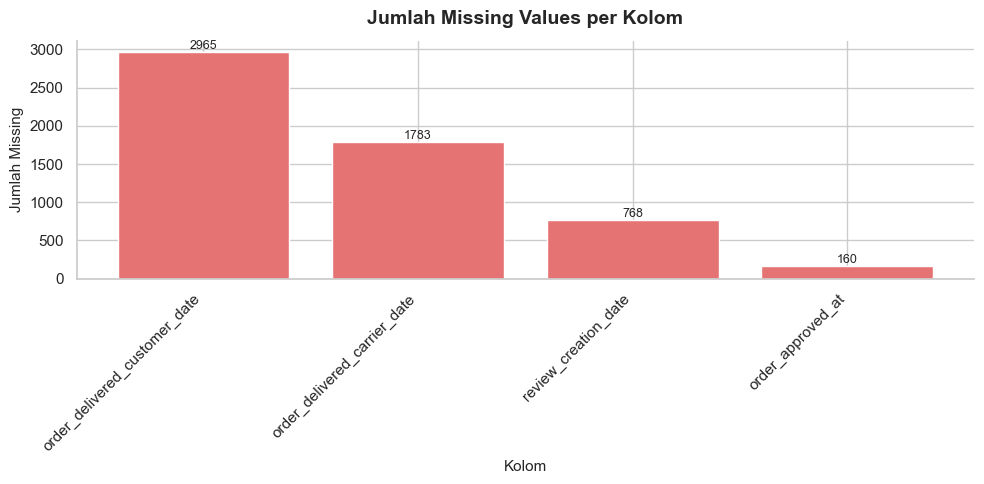

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_plot = df.isnull().sum()
missing_plot = missing_plot[missing_plot > 0].sort_values(ascending=False)

if not missing_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(missing_plot.index, missing_plot.values, color='#e57373', edgecolor='white')
    ax.set_title('Jumlah Missing Values per Kolom', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Kolom', fontsize=11)
    ax.set_ylabel('Jumlah Missing', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada missing values — tidak ada grafik yang ditampilkan.')

**Insight Missing Values:**

- Kolom datetime seperti `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` memiliki null karena order belum melewati tahap tersebut (wajar).
- Kolom `review_comment_message` null karena tidak semua pelanggan mengisi komentar.
- Kolom `primary_category` null karena beberapa produk tidak memiliki kategori atau terjemahan.
- Kolom kunci analisis (`order_id`, `customer_id`, `total_payment`) perlu diperiksa lebih lanjut.

### 3.3 Duplikasi Data

In [21]:
print('=' * 60)
print('PEMERIKSAAN DUPLIKASI DATA')
print('=' * 60)

# Duplikasi baris penuh
dup_full = df.duplicated().sum()
print(f'Duplikasi baris penuh          : {dup_full}')

# Duplikasi berdasarkan order_id
dup_order = df.duplicated(subset=['order_id']).sum()
print(f'Duplikasi berdasarkan order_id : {dup_order}')

# Duplikasi berdasarkan customer_id
dup_customer = df.duplicated(subset=['customer_id']).sum()
print(f'Duplikasi berdasarkan customer_id : {dup_customer}')
print()
print(f'Catatan: customer_id boleh muncul >1 kali (satu pelanggan bisa punya banyak order).')

PEMERIKSAAN DUPLIKASI DATA
Duplikasi baris penuh          : 0
Duplikasi berdasarkan order_id : 0
Duplikasi berdasarkan customer_id : 0

Catatan: customer_id boleh muncul >1 kali (satu pelanggan bisa punya banyak order).


In [22]:
print('=' * 60)
print('SAMPLE BARIS DUPLIKAT (jika ada)')
print('=' * 60)

dup_rows = df[df.duplicated(subset=['order_id'], keep=False)]

if dup_rows.empty:
    print('Tidak ditemukan duplikasi berdasarkan order_id.')
else:
    print(f'Ditemukan {len(dup_rows)} baris duplikat berdasarkan order_id:')
    display(dup_rows[['order_id', 'customer_id', 'order_status', 'total_payment']].head(10))

SAMPLE BARIS DUPLIKAT (jika ada)
Tidak ditemukan duplikasi berdasarkan order_id.


### 3.4 Outlier

In [23]:
print('=' * 60)
print('DETEKSI OUTLIER — METODE IQR')
print('=' * 60)

numeric_cols = ['total_price', 'total_freight', 'total_items', 'total_payment']
numeric_cols = [col for col in numeric_cols if col in df.columns]

outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_outlier = df[(df[col] < low) | (df[col] > high)].shape[0]
    pct = round(n_outlier / len(df) * 100, 2)
    outlier_summary.append({
        'Kolom': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Batas Bawah (low)': round(low, 2),
        'Batas Atas (high)': round(high, 2),
        'Jumlah Outlier': n_outlier,
        'Persentase (%)': pct
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

DETEKSI OUTLIER — METODE IQR


,Kolom,Q1,Q3,IQR,Batas Bawah (low),Batas Atas (high),Jumlah Outlier,Persentase (%)
0,total_price,45.00,149.90,104.90,-112.35,307.25,7903,7.95
1,total_freight,13.72,23.92,10.20,-1.58,39.22,9992,10.05
2,total_items,1.00,1.00,0.00,1.00,1.00,10578,10.64
3,total_payment,62.01,176.97,114.96,-110.43,349.41,7866,7.91


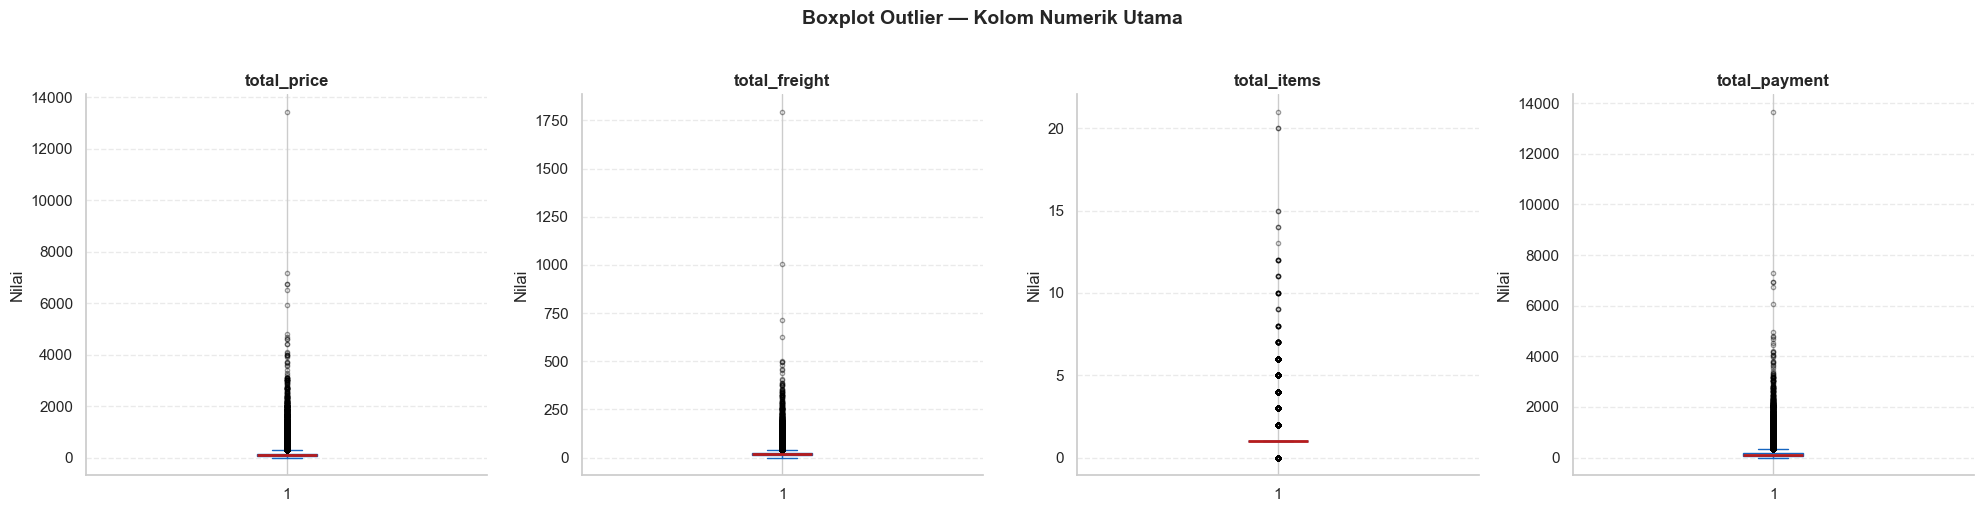

In [24]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))

if len(numeric_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
               medianprops=dict(color='#B71C1C', linewidth=2),
               whiskerprops=dict(color='#1565C0'),
               capprops=dict(color='#1565C0'),
               flierprops=dict(marker='o', color='#e57373', alpha=0.4, markersize=3))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Nilai')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(ax=ax)

plt.suptitle('Boxplot Outlier — Kolom Numerik Utama', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight Outlier:**

- Terdapat outlier pada seluruh kolom numerik utama, terutama `total_payment` dan `total_price`.
- Outlier **dipertahankan** karena merepresentasikan transaksi nyata yang valid (order bernilai besar bisa terjadi di e-commerce).
- Keberadaan outlier akan diperhitungkan saat interpretasi hasil analisis, terutama pada rata-rata revenue.

### 3.5 Konsistensi Data

In [25]:
print('=' * 60)
print('KONSISTENSI — DISTRIBUSI order_status')
print('=' * 60)

status_counts = df['order_status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(2)

status_df = pd.DataFrame({
    'Jumlah': status_counts,
    'Persentase (%)': status_pct
})
display(status_df)

KONSISTENSI — DISTRIBUSI order_status


,Jumlah,Persentase (%)
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


In [26]:
print('=' * 60)
print('KONSISTENSI — RENTANG TANGGAL ORDER')
print('=' * 60)

if 'order_purchase_timestamp' in df.columns:
    ts = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
    print(f'Tanggal order terlama  : {ts.min()}')
    print(f'Tanggal order terbaru  : {ts.max()}')
    print(f'Rentang waktu          : {(ts.max() - ts.min()).days} hari')
    print(f'Nilai null pada kolom  : {ts.isnull().sum()}')

KONSISTENSI — RENTANG TANGGAL ORDER
Tanggal order terlama  : 2016-09-04 21:15:19
Tanggal order terbaru  : 2018-10-17 17:30:18
Rentang waktu          : 772 hari
Nilai null pada kolom  : 0


In [27]:
print('=' * 60)
print('KONSISTENSI — NILAI NEGATIF PADA KOLOM NUMERIK')
print('=' * 60)

for col in numeric_cols:
    n_neg = (df[col] < 0).sum()
    print(f'{col:<20} : {n_neg} nilai negatif')

KONSISTENSI — NILAI NEGATIF PADA KOLOM NUMERIK
total_price          : 0 nilai negatif
total_freight        : 0 nilai negatif
total_items          : 0 nilai negatif
total_payment        : 0 nilai negatif


In [28]:
print('=' * 60)
print('KONSISTENSI — REVIEW SCORE')
print('=' * 60)

if 'review_score' in df.columns:
    review_counts = df['review_score'].value_counts().sort_index()
    display(review_counts.rename('Jumlah').to_frame())
    invalid_score = df[~df['review_score'].isin([0, 1, 2, 3, 4, 5])]['review_score'].count()
    print(f'\nNilai di luar range 0-5: {invalid_score}')

KONSISTENSI — REVIEW SCORE


,Jumlah
review_score,
0,768
1,11360
2,3128
3,8120
4,19046
5,57019



Nilai di luar range 0-5: 0


In [29]:
print('=' * 60)
print('KONSISTENSI — DISTRIBUSI KATEGORI PRODUK')
print('=' * 60)

cat_col = 'primary_category' if 'primary_category' in df.columns else None

if cat_col:
    top_cat = df[cat_col].value_counts().head(10)
    print('Top 10 kategori produk:')
    display(top_cat.rename('Jumlah Order').to_frame())
    n_unknown = (df[cat_col] == 'Unknown').sum() if 'Unknown' in df[cat_col].values else df[cat_col].isnull().sum()
    print(f'\nJumlah order tanpa kategori (Unknown/null): {n_unknown}')

KONSISTENSI — DISTRIBUSI KATEGORI PRODUK
Top 10 kategori produk:


,Jumlah Order
primary_category,
bed_bath_table,9385
health_beauty,8810
sports_leisure,7668
computers_accessories,6679
furniture_decor,6350
housewares,5812
watches_gifts,5584
telephony,4177
auto,3891



Jumlah order tanpa kategori (Unknown/null): 2185


### 3.6 Ringkasan Hasil Assessing Data

In [30]:
print('=' * 60)
print('RINGKASAN HASIL ASSESSING DATA')
print('=' * 60)

total_missing = df.isnull().sum().sum()
cols_with_missing = (df.isnull().sum() > 0).sum()
dup_order = df.duplicated(subset=['order_id']).sum()
dup_full = df.duplicated().sum()

summary = [
    ('Jumlah Baris', f"{df.shape[0]:,}"),
    ('Jumlah Kolom', f"{df.shape[1]}"),
    ('Total Missing Values', f"{total_missing:,}"),
    ('Kolom dengan Missing Values', f"{cols_with_missing}"),
    ('Duplikasi Baris Penuh', f"{dup_full}"),
    ('Duplikasi Berdasarkan order_id', f"{dup_order}"),
    ('Outlier (dipertahankan)', 'Ada pada total_price, total_freight, total_items, total_payment'),
    ('Nilai Negatif', 'Diperiksa per kolom numerik'),
    ('Inkonsistensi Kategori', 'Beberapa produk tanpa kategori (Unknown)'),
    ('Rentang Waktu Data', f"{pd.to_datetime(df['order_purchase_timestamp'], errors='coerce').min().date()} s.d. {pd.to_datetime(df['order_purchase_timestamp'], errors='coerce').max().date()}")
]

summary_df = pd.DataFrame(summary, columns=['Aspek', 'Hasil'])
display(summary_df)

print()
print('Kesimpulan:')
print('- Missing values perlu ditangani pada tahap Data Cleaning.')
print('- Tidak ada duplikasi kritis berdasarkan order_id.')
print('- Outlier dipertahankan karena merepresentasikan transaksi valid.')
print('- Tipe data datetime perlu dikonversi sebelum analisis lanjutan.')

RINGKASAN HASIL ASSESSING DATA


,Aspek,Hasil
0,Jumlah Baris,"99,441"
1,Jumlah Kolom,24
2,Total Missing Values,"5,676"
3,Kolom dengan Missing Values,4
4,Duplikasi Baris Penuh,0
5,Duplikasi Berdasarkan order_id,0
6,Outlier (dipertahankan),"Ada pada total_price, total_freight, total_ite..."
7,Nilai Negatif,Diperiksa per kolom numerik
8,Inkonsistensi Kategori,Beberapa produk tanpa kategori (Unknown)
9,Rentang Waktu Data,2016-09-04 s.d. 2018-10-17



Kesimpulan:
- Missing values perlu ditangani pada tahap Data Cleaning.
- Tidak ada duplikasi kritis berdasarkan order_id.
- Outlier dipertahankan karena merepresentasikan transaksi valid.
- Tipe data datetime perlu dikonversi sebelum analisis lanjutan.


## 4. Data Cleaning

Periksa missing values, duplikasi, statistik dasar, lalu lakukan pembersihan data.

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nDataframe shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nSummary statistics:')
display(df.describe(include='all'))


Missing values per column:
order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  160
order_delivered_carrier_date      1783
order_delivered_customer_date     2965
order_estimated_delivery_date        0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
total_price                        775
total_freight                      775
total_items                        775
total_payment                        1
max_installment                      1
review_score                       768
review_comment_message           58660
review_creation_date               768
primary_category                  2185
dtype: int64

Duplicate rows: 0

Dataframe shape: (99441, 21)

Column names: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'orde

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,customer_state,total_price,total_freight,total_items,total_payment,max_installment,review_score,review_comment_message,review_creation_date,primary_category
count,99441,99441,99441,99441,99281,97658,96476,99441,99441,99441.000000,...,99441,98666.000000,98666.000000,98666.000000,99440.000000,99440.000000,98673.000000,40781,98673,97256
unique,99441,99441,8,98875,90733,81018,95664,459,96096,NaN,...,27,NaN,NaN,NaN,NaN,NaN,NaN,36063,636,71
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,...,SP,NaN,NaN,NaN,NaN,NaN,NaN,Muito bom,2017-12-19 00:00:00,bed_bath_table
freq,1,1,96478,3,9,47,3,522,17,NaN,...,41746,NaN,NaN,NaN,NaN,NaN,NaN,229,461,9385
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35137.474583,...,NaN,137.754076,22.823562,1.141731,160.990267,2.930521,4.086782,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29797.938996,...,NaN,210.645145,21.650909,0.538452,221.951257,2.715685,1.347438,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1003.000000,...,NaN,0.850000,0.000000,1.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11347.000000,...,NaN,45.900000,13.850000,1.000000,62.010000,1.000000,4.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24416.000000,...,NaN,86.900000,17.170000,1.000000,105.290000,2.000000,5.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58900.000000,...,NaN,149.900000,24.040000,1.000000,176.970000,4.000000,5.000000,NaN,NaN,NaN


### Handling missing values

Untuk analisis ini, nilai yang hilang pada fitur numerik akan diisi dengan 0 jika relevan, sedangkan pada fitur kategori dan teks akan diisi dengan placeholder informatif.

In [6]:
# Fill numeric columns

df['total_price'] = df['total_price'].fillna(0)

df['total_freight'] = df['total_freight'].fillna(0)

df['total_items'] = df['total_items'].fillna(0).astype(int)

df['total_payment'] = df['total_payment'].fillna(0)

df['max_installment'] = df['max_installment'].fillna(0).astype(int)

df['review_score'] = df['review_score'].fillna(0).astype(int)



# Fill categorical columns

df['primary_category'] = df['primary_category'].fillna('Unknown')

df['review_comment_message'] = df['review_comment_message'].fillna('No comment')

if 'customer_state' in df.columns:

    df['customer_state'] = df['customer_state'].fillna('Unknown')

if 'customer_city' in df.columns:

    df['customer_city'] = df['customer_city'].fillna('Unknown')



# Convert datetime columns where possible

datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_creation_date']

for col in datetime_cols:

    if col in df.columns:

        df[col] = pd.to_datetime(df[col], errors='coerce')



# Drop duplicated order rows if ditemukan

df = df.drop_duplicates(subset=['order_id'])



print('After cleaning shape:', df.shape)

print('Duplicate rows after drop:', df.duplicated(subset=['order_id']).sum())


After cleaning shape: (99441, 21)
Duplicate rows after drop: 0


### Outlier handling

Outlier diperiksa di variabel revenue dan total_items. Nilai ekstrim tetap dipertahankan kecuali jika tidak bermakna untuk analisis.

In [7]:
numeric_cols = ['total_price', 'total_freight', 'total_items', 'total_payment']
for col in numeric_cols:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        outliers = df[(df[col] < low) | (df[col] > high)]
        print(f'{col}: {len(outliers)} outliers, low={low:.2f}, high={high:.2f}')

total_price: 7903 outliers, low=-112.35, high=307.25
total_freight: 9992 outliers, low=-1.58, high=39.22
total_items: 10578 outliers, low=1.00, high=1.00
total_payment: 7866 outliers, low=-110.43, high=349.41


## 5. Feature Engineering

Tambahkan fitur baru yang berguna untuk analisis waktu dan revenue.

In [8]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['revenue'] = df['total_payment']

print(df[['order_id', 'order_month', 'order_year', 'revenue']].head())

                           order_id order_month  order_year  revenue
0  e481f51cbdc54678b7cc49136f2d6af7     2017-10        2017    38.71
1  53cdb2fc8bc7dce0b6741e2150273451     2018-07        2018   141.46
2  47770eb9100c2d0c44946d9cf07ec65d     2018-08        2018   179.12
3  949d5b44dbf5de918fe9c16f97b45f8a     2017-11        2017    72.20
4  ad21c59c0840e6cb83a9ceb5573f8159     2018-02        2018    28.62


## 6. Simpan Data

Simpan hasil olahan utama ke `dashboard/main_data.csv`. Analisis lanjutan akan menggunakan file ini.

In [9]:
df.to_csv('dashboard/main_data.csv', index=False)
print('Saved dashboard/main_data.csv with shape', df.shape)

Saved dashboard/main_data.csv with shape (99441, 24)


## 7. Load Main Data

Muat ulang `dashboard/main_data.csv` untuk memastikan analisis selanjutnya menggunakan file hasil akhir.

In [10]:
df = pd.read_csv('dashboard/main_data.csv')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'], errors='coerce')
print('Reloaded main data shape:', df.shape)
print(df[['order_purchase_timestamp', 'order_month', 'order_year', 'revenue']].head())

Reloaded main data shape: (99441, 24)
  order_purchase_timestamp order_month  order_year  revenue
0      2017-10-02 10:56:33     2017-10        2017    38.71
1      2018-07-24 20:41:37     2018-07        2018   141.46
2      2018-08-08 08:38:49     2018-08        2018   179.12
3      2017-11-18 19:28:06     2017-11        2017    72.20
4      2018-02-13 21:18:39     2018-02        2018    28.62


## 8. Exploratory Data Analysis (EDA)

Analisis EDA akan menjawab pertanyaan bisnis dengan ringkasan agregasi dan visualisasi awal.

In [11]:
revenue_monthly = df.groupby('order_month').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index()

revenue_category = df.groupby('primary_category').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index().sort_values('revenue', ascending=False)

revenue_state = df.groupby('customer_state').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index().sort_values('revenue', ascending=False)

display(revenue_monthly.head(10))
display(revenue_category.head(10))
display(revenue_state.head(10))

,order_month,revenue,orders
0,2016-09,252.24,4
1,2016-10,59090.48,324
2,2016-12,19.62,1
3,2017-01,138488.04,800
4,2017-02,291908.01,1780
5,2017-03,449863.60,2682
6,2017-04,417788.03,2404
7,2017-05,592918.82,3700
8,2017-06,511276.38,3245
9,2017-07,592382.92,4026


,primary_category,revenue,orders
44,health_beauty,1443182.68,8810
71,watches_gifts,1299139.04,5584
8,bed_bath_table,1257907.93,9385
66,sports_leisure,1154092.27,7668
16,computers_accessories,1063925.67,6679
40,furniture_decor,907045.66,6350
50,housewares,775139.40,5812
21,cool_stuff,716406.30,3589
6,auto,687648.92,3891
43,garden_tools,583237.30,3479


,customer_state,revenue,orders
25,SP,5998226.96,41746
18,RJ,2144379.69,12852
10,MG,1872257.26,11635
22,RS,890898.54,5466
17,PR,811156.38,5045
23,SC,623086.43,3637
4,BA,616645.82,3380
6,DF,355141.08,2140
8,GO,350092.31,2020
7,ES,325967.55,2033


## Insight Jawaban Business Questions



- **Pertanyaan 1:** Berdasarkan agregasi `revenue_monthly`, tren revenue dan jumlah order per bulan selama 2017–2018 dapat dilihat dalam pola musiman. Bulan-bulan tertentu menunjukkan puncak revenue dan volume order lebih tinggi, sehingga tim dapat merencanakan promosi dan stok untuk periode high-demand.



- **Pertanyaan 2:** Berdasarkan agregasi `revenue_category`, kategori produk dengan revenue tertinggi teridentifikasi dari peringkat teratas. Kategori ini merupakan prioritas utama untuk fokus pemasaran dan manajemen inventori karena memberikan kontribusi pendapatan terbesar.



- **Pertanyaan 3:** Berdasarkan agregasi `revenue_state`, state pelanggan dengan kontribusi penjualan terbesar muncul sebagai target geografis utama. State-state teratas ini penting untuk strategi penetrasi pasar dan kampanye pemasaran berbasis wilayah.


## 9. Visualisasi Data

Gunakan `matplotlib` dan `seaborn` untuk menampilkan tren dan top performa kategori serta state.

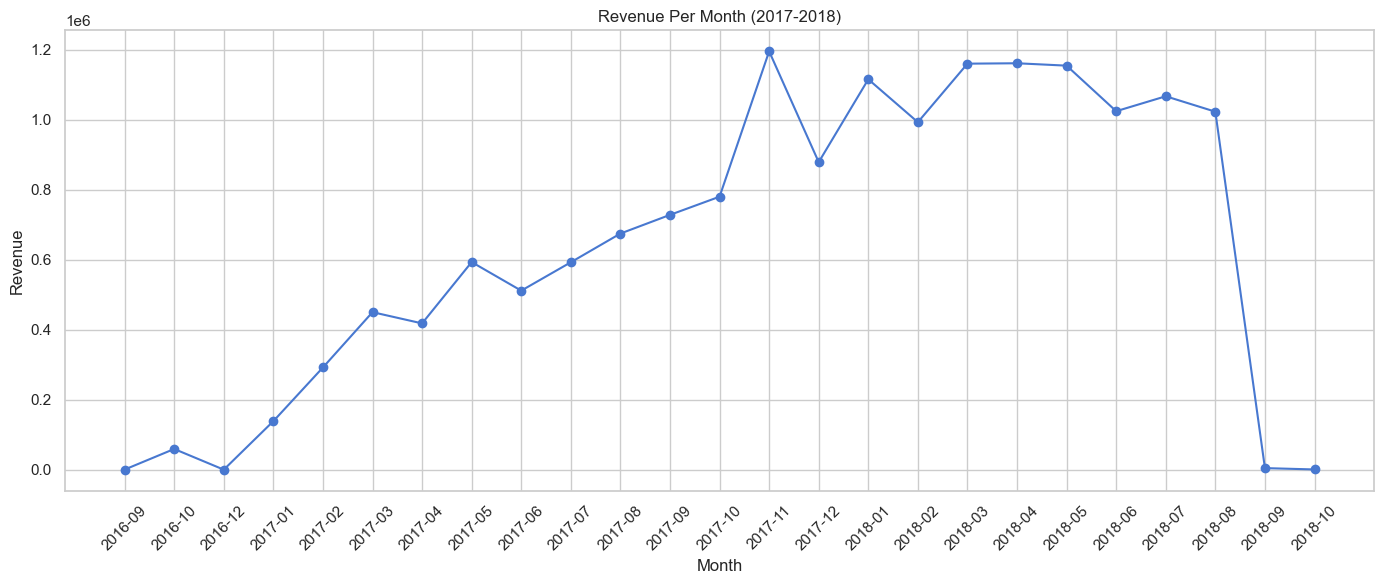

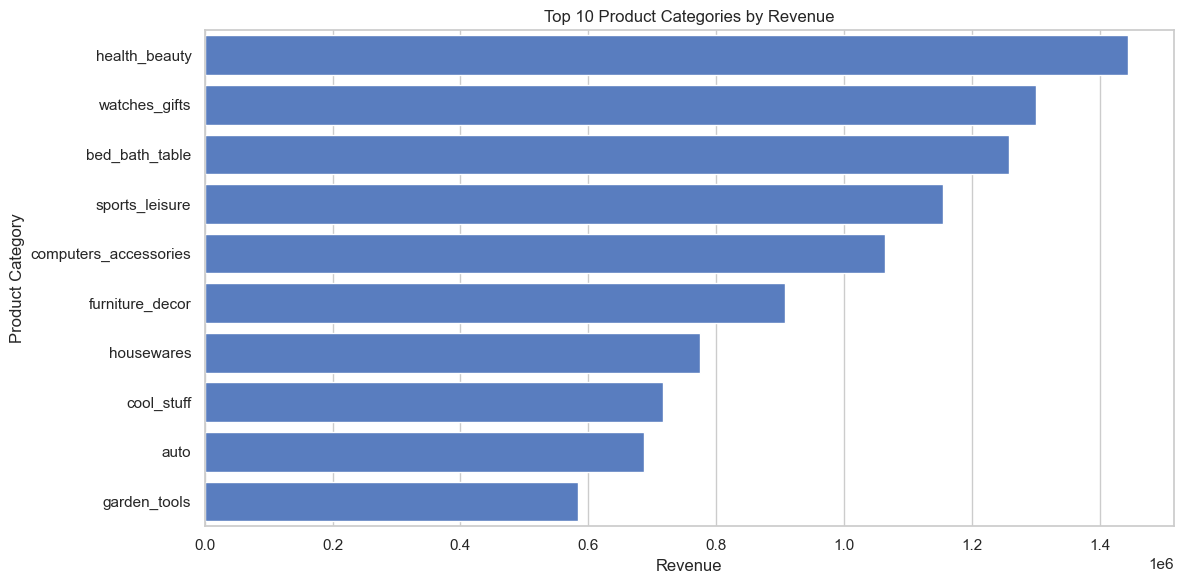

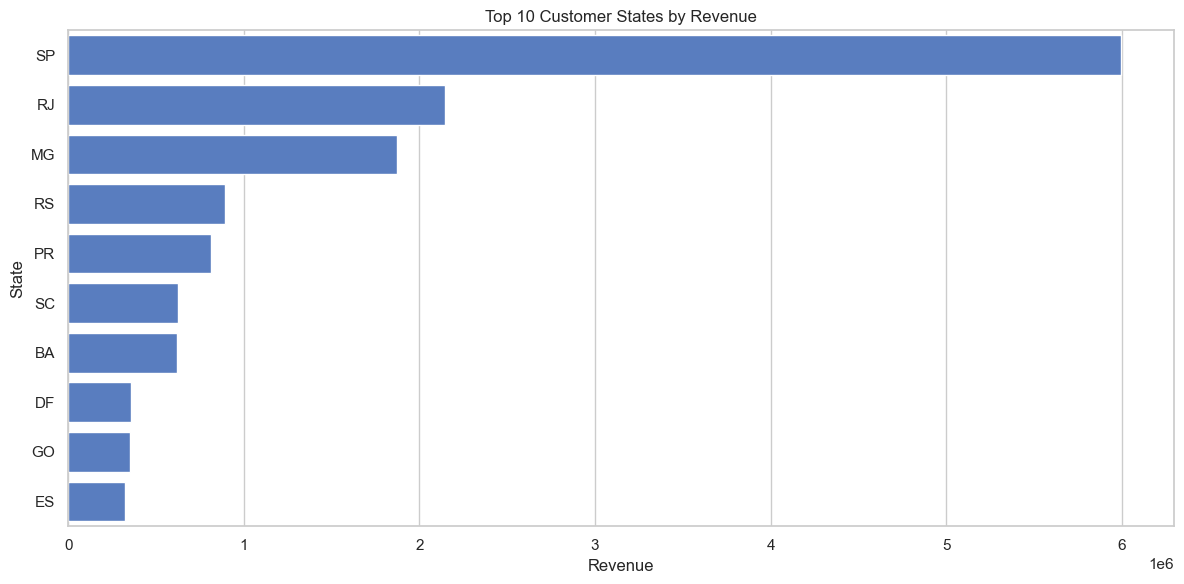

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted')

# Line chart revenue per month
plt.figure(figsize=(14, 6))
plt.plot(revenue_monthly['order_month'], revenue_monthly['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Revenue Per Month (2017-2018)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Bar chart top 10 categories by revenue
top_categories = revenue_category.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='revenue', y='primary_category')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

# Bar chart top state by revenue
top_states = revenue_state.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_states, x='revenue', y='customer_state')
plt.title('Top 10 Customer States by Revenue')
plt.xlabel('Revenue')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Insight Visualisasi

- Tren bulanan menunjukkan periode puncak revenue dan pergeseran volume order.
- Top kategori produk membantu menentukan fokus stok dan promosi.
- State dengan revenue terbesar memberikan wawasan geografi pelanggan terbaik.

## 10. Advanced Analysis (RFM)

Analisis RFM dilakukan berdasarkan customer_id untuk mengidentifikasi nilai pelanggan dari sisi recency, frequency, dan monetary.

In [13]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'count'),
    Monetary=('revenue', 'sum')
).reset_index()

# Gunakan rank untuk menghindari error qcut
rfm['RecencySegment'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    q=3,
    labels=['High Value', 'Mid Value', 'Low Value']
)

rfm['FrequencySegment'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=3,
    labels=['Low Value', 'Mid Value', 'High Value']
)

rfm['MonetarySegment'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=3,
    labels=['Low Value', 'Mid Value', 'High Value']
)

display(rfm.head())

,customer_id,Recency,Frequency,Monetary,RecencySegment,FrequencySegment,MonetarySegment
0,00012a2ce6f8dcda20d059ce98491703,338,1,114.74,Mid Value,Low Value,Mid Value
1,000161a058600d5901f007fab4c27140,459,1,67.41,Low Value,Low Value,Low Value
2,0001fd6190edaaf884bcaf3d49edf079,597,1,195.42,Low Value,Low Value,High Value
3,0002414f95344307404f0ace7a26f1d5,428,1,179.35,Low Value,Low Value,High Value
4,000379cdec625522490c315e70c7a9fb,199,1,107.01,High Value,Low Value,Mid Value


## 11. Visualisasi RFM

Visualisasi segmentos pelanggan dan distribusi monetary membantu memahami pola nilai pelanggan.

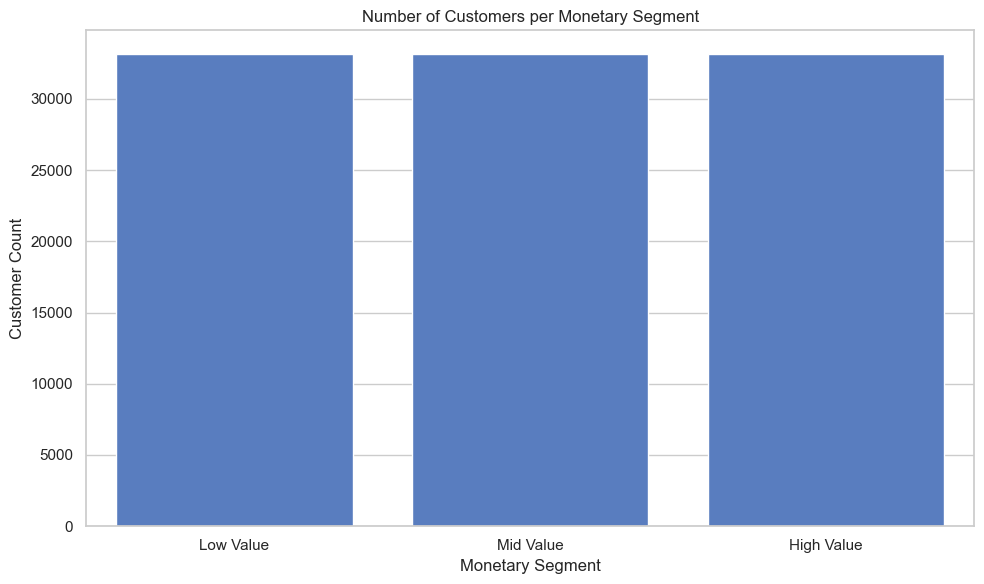

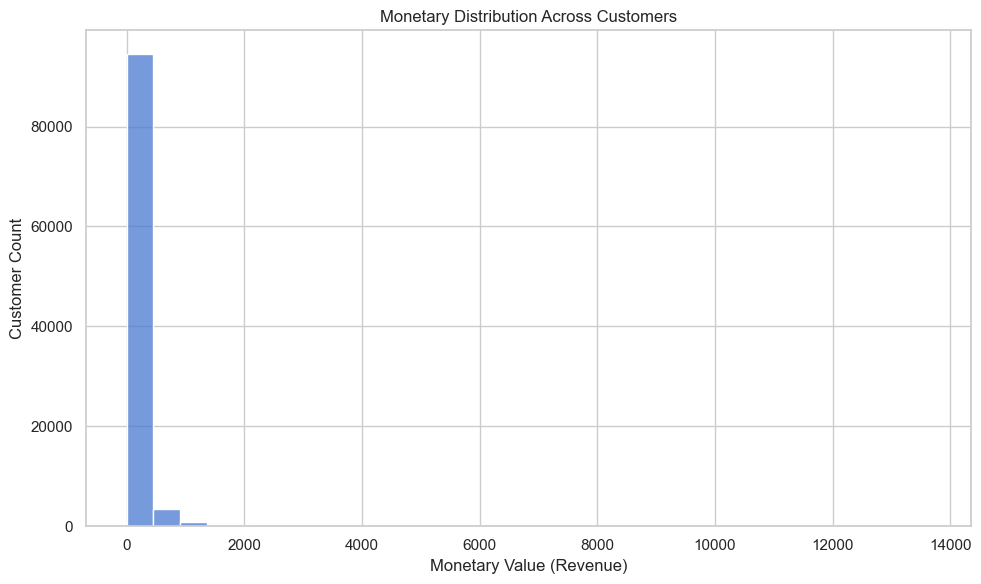

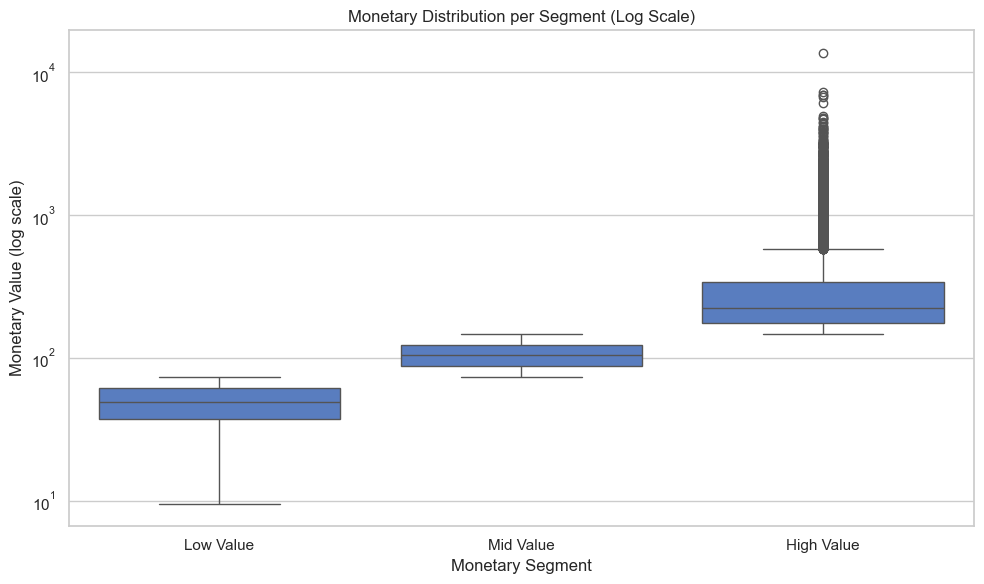

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='MonetarySegment', order=['Low Value', 'Mid Value', 'High Value'])
plt.title('Number of Customers per Monetary Segment')
plt.xlabel('Monetary Segment')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(rfm['Monetary'], bins=30, kde=False)
plt.title('Monetary Distribution Across Customers')
plt.xlabel('Monetary Value (Revenue)')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=rfm, x='MonetarySegment', y='Monetary', order=['Low Value', 'Mid Value', 'High Value'])
plt.yscale('log')
plt.title('Monetary Distribution per Segment (Log Scale)')
plt.xlabel('Monetary Segment')
plt.ylabel('Monetary Value (log scale)')
plt.tight_layout()
plt.show()

## Insight Monetary Distribution per Segment 
Berdasarkan visualisasi boxplot pada skala logaritmik, terlihat perbedaan yang jelas pada distribusi nilai transaksi (Monetary) di setiap segmen pelanggan.

Segmentasi menunjukkan bahwa nilai median meningkat secara konsisten dari Low Value ke Mid Value hingga High Value, yang menandakan bahwa metode segmentasi RFM telah berhasil mengelompokkan pelanggan sesuai dengan tingkat kontribusi revenue mereka.

Selain itu, segmen High Value memiliki penyebaran data yang jauh lebih luas dibandingkan segmen lainnya. Hal ini menunjukkan bahwa pelanggan dalam kategori ini tidak homogen, melainkan terdiri dari berbagai tingkat pengeluaran, mulai dari yang cukup tinggi hingga yang sangat tinggi.

Terlihat pula adanya banyak outlier pada segmen High Value, bahkan dengan nilai yang sangat ekstrem. Kondisi ini mengindikasikan bahwa sebagian kecil pelanggan memberikan kontribusi revenue yang sangat besar, yang sejalan dengan konsep Pareto (80/20 rule), di mana sebagian kecil pelanggan menyumbang sebagian besar pendapatan.

Sebaliknya, segmen Low Value dan Mid Value memiliki distribusi yang lebih sempit dan stabil, dengan jumlah outlier yang relatif sedikit. Hal ini menunjukkan bahwa pelanggan dalam kedua segmen tersebut memiliki pola transaksi yang lebih konsisten namun dengan nilai yang lebih rendah.

Meskipun telah menggunakan skala logaritmik, distribusi data masih menunjukkan kecenderungan right-skewed. Hal ini merupakan karakteristik umum dalam data transaksi e-commerce, di mana mayoritas pelanggan memiliki nilai pembelian kecil, sementara hanya sebagian kecil yang memiliki nilai pembelian sangat besar.

## 12. Conclusion & Recommendation

Kesimpulan berikut merangkum jawaban atas pertanyaan bisnis dan rekomendasi tindakan.

- Tren revenue dan jumlah order per bulan memperlihatkan pola musiman yang penting untuk perencanaan promosi.
- Kategori produk dengan revenue tertinggi menunjukkan area fokus produk yang paling menguntungkan.
- State dengan kontribusi penjualan terbesar merupakan target utama untuk kampanye pemasaran lokal.

### Rekomendasi
- Fokuskan promosi dan persediaan pada kategori produk top dan state dengan revenue terbesar untuk meningkatkan penjualan.
- Gunakan hasil RFM untuk menawarkan diskon personal kepada pelanggan `High Value` dan mempertahankan mereka lebih lama.